## Compare EDELWEISS to VIIRS

In [18]:
from edelassim.observations import EdelweissGrandesRoussesGrid

data_folder = "/home/imperatoren/work/edelweiss_assimilation/observation_operator/data/grandesrousses"
simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousses250m"
period = slice("2021-11-01", "2022-07-01")
grandesrousses_grid = EdelweissGrandesRoussesGrid()

In [19]:
import xarray as xr
from edelassim.bdclim import crop_bdclim, find_station_locations
from edelassim.observations import scale_virrs

forest_mask_path = f"{data_folder}/forest_mask/corine_grandesrousses_max.nc"
forest_mask = xr.open_dataarray(forest_mask_path, engine="rasterio").sel(band=1).drop_vars("band")

no_assim_all_path = f"{simulation_folder}/open_loop/all_members/pro/PRO_GrandesRousses250m_2021080206_2022080106.nc"
edel = xr.open_dataset(no_assim_all_path).where(forest_mask == 0).sel(time=period).data_vars["DSN_T_ISBA"]

viirs_filepath = f"{data_folder}/reprojected_from_france_viirs/mf_fsc_l3_grandesrousses_wy_2021_2022.nc"
viirs = scale_virrs(xr.open_dataset(viirs_filepath).where(forest_mask == 0).sel(time=period).data_vars["snow_cover_fraction"])

pleiades_path = f"{data_folder}/pleiades_time_series/pleaides_granderousses_all.nc"
pleiades = xr.open_dataset(pleiades_path).where(forest_mask == 0).sel(time=period).data_vars["snow_depth"]

bdclim_path = "/home/imperatoren/work/edelweiss_assimilation/data/snow_depth/bdclim/snow_depth_bdclim.nc"
bdclim = crop_bdclim(bdclim_path, grid=grandesrousses_grid).data_vars["neigetotx"].sel(time=period) / 100
x_poste, y_poste = find_station_locations(bdclim_dataset=bdclim)

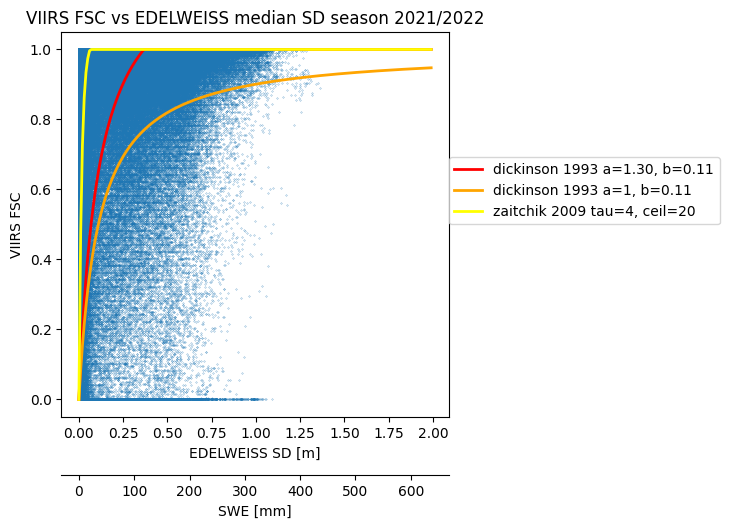

In [64]:
from matplotlib import pyplot as plt
import numpy as np
from edelassim.observation_operators import dickinson, zaitchik
from edelassim.swe import sd_to_swe, swe_to_sd

fig, ax = plt.subplots(figsize=(5, 5))
sd = edel.sel(x=viirs["x"], y=viirs["y"], method="nearest", time=viirs.coords["time"]).sel(member=1)  # .median(dim="member")
am, bm = 1.3, 0.11
tau, ceil = 4, 20
mean_snow_density = 320  # kg/m3
sd_axis = np.arange(0, 2, 0.01)  # m


swe_axis = sd_to_swe(sd_axis)


ax.scatter(sd, viirs, s=0.04)
ax.plot(
    sd_axis,
    dickinson(sd=sd_axis, a=am, b=bm),
    "r",
    linewidth=2,
    label=f"dickinson 1993 a={am:.2f}, b={bm:.2f}",
)
ax.plot(
    sd_axis,
    dickinson(sd=sd_axis, a=1, b=0.11),
    "orange",
    linewidth=2,
    label="dickinson 1993 a=1, b=0.11",
)
ax.plot(
    sd_axis,
    zaitchik(swe=swe_axis, tau_scf=tau, swe_full_snow_cover=ceil),
    "yellow",
    linewidth=2,
    label=f"zaitchik 2009 tau={tau}, ceil={ceil}",
)
# ax.plot(np.arange(0, 2, 0.01), dickinson(sd=np.arange(0, 2, 0.01), a=am, b=bm), "r", linewidth=2)
ax.set_title("VIIRS FSC vs EDELWEISS median SD season 2021/2022")
ax.set_ylabel("VIIRS FSC")
ax.set_xlabel("EDELWEISS SD [m]")
secax = ax.secondary_xaxis(-0.15, functions=(sd_to_swe, swe_to_sd))
secax.set_xlabel("SWE [mm]")
ax.legend(loc=(1, 0.5))

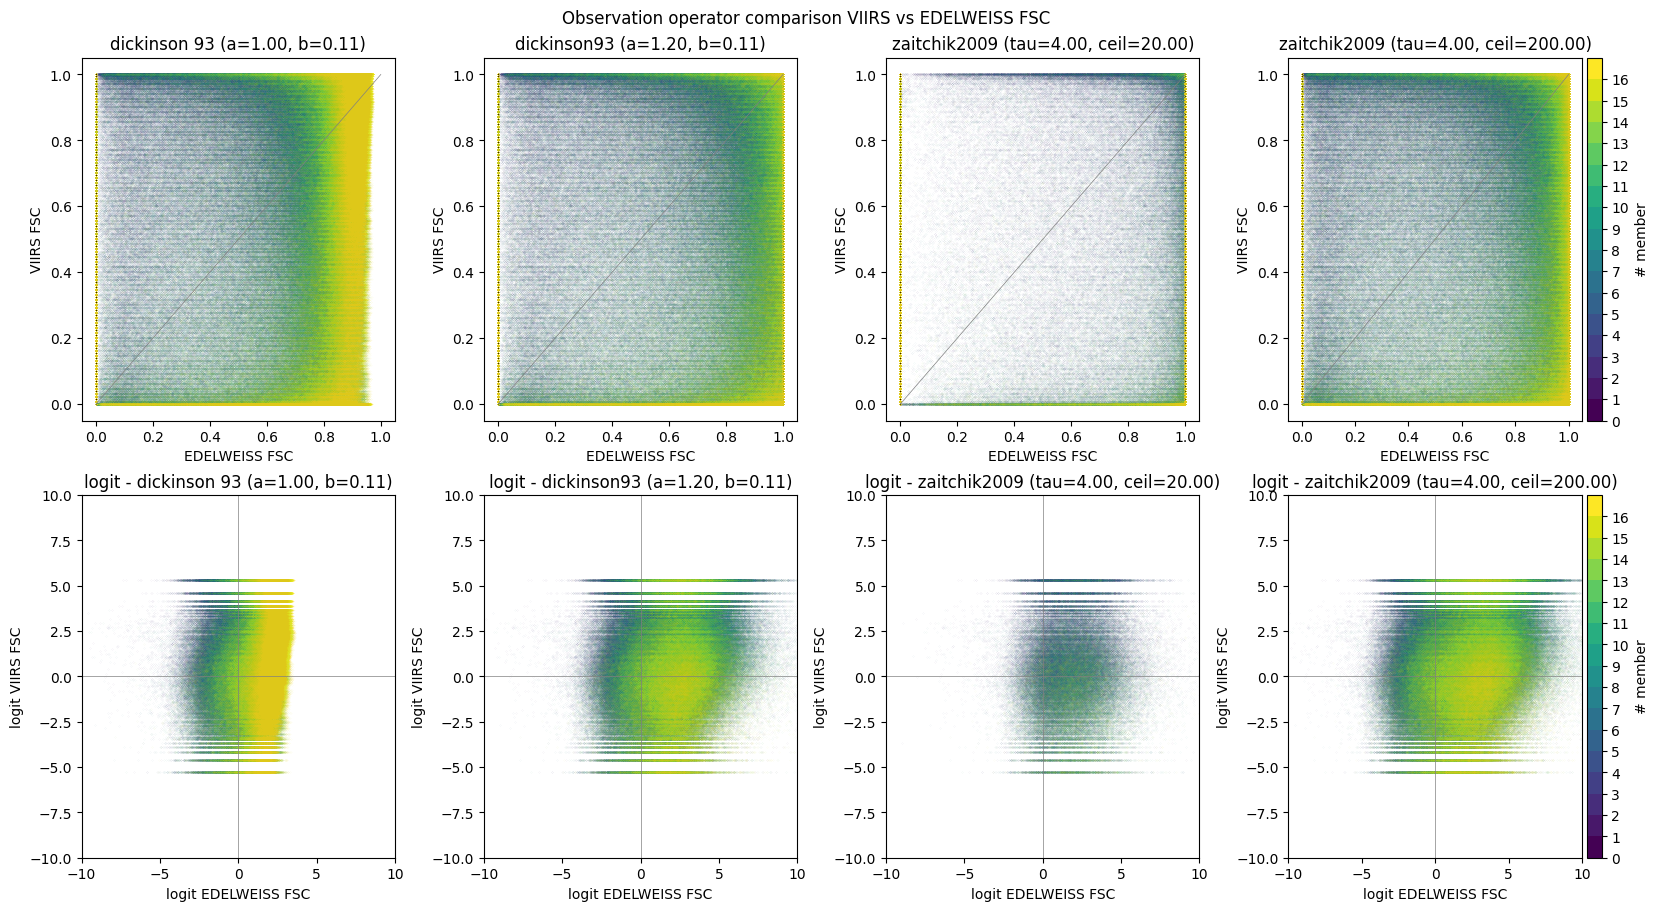

In [ ]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import logit
import numpy as np
from edelassim.observation_operators import dickinson, zaitchik
from edelassim.swe import sd_to_swe
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable


def draw_member_clorbar(n_members: int, aax: Axes):
    divider = make_axes_locatable(aax)
    ax_cb = divider.new_horizontal(size="5%", pad=0.05)
    members = np.arange(n_members)
    cbar = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=colormap.resampled(n_members), orientation="vertical")
    cbar.ax.set_yticks(members / n_members)
    cbar.ax.set_yticklabels(members)
    cbar.set_label("# member")
    plt.gcf().add_axes(ax_cb)


fig, axs = plt.subplots(2, 4, figsize=(16, 9), constrained_layout=True)
fig.suptitle("Observation operator comparison VIIRS vs EDELWEISS FSC")
edel_sd = edel.sel(x=viirs["x"], y=viirs["y"], method="nearest", time=viirs.coords["time"])
a0, b0 = 1, 0.11
a_calib, b_calib = 1.2, 0.11
tau0, ceil0 = 4, 20
tau_calib, ceil_calib = 4, 200

colormap = plt.cm.viridis  # nipy_spectral, Set1,Paired
colorst = [colormap(i) for i in np.linspace(0, 1, 17)]

viirs_flatten = viirs.values.ravel()
# viirs_flatten = np.where(viirs_flatten < 1, viirs_flatten, np.nan)
# viirs_flatten = np.where(viirs_flatten > 0, viirs_flatten, np.nan)

for member in edel_sd.coords["member"]:
    edel_fsc = dickinson(edel_sd.sel(member=member), a0, b0).values.ravel()
    # edel_fsc = np.where(edel_fsc < 1, edel_fsc, np.nan)
    # edel_fsc = np.where(edel_fsc > 0, edel_fsc, np.nan)
    axs[0, 0].plot(edel_fsc, viirs_flatten, ".", color=colorst[member.values], markersize=0.04)
    axs[0, 0].set_title(f"dickinson 93 (a={a0:.2f}, b={b0:.2f})")
    axs[1, 0].plot(logit(edel_fsc), logit(viirs_flatten), ".", color=colorst[member.values], markersize=0.04)
    axs[1, 0].set_title(f"logit - dickinson 93 (a={a0:.2f}, b={b0:.2f})")

for member in edel_sd.coords["member"]:
    edel_fsc = dickinson(edel_sd.sel(member=member), a_calib, b_calib).values.ravel()
    # edel_fsc = np.where(edel_fsc < 1, edel_fsc, np.nan)
    # edel_fsc = np.where(edel_fsc > 0, edel_fsc, np.nan)
    axs[0, 1].plot(edel_fsc, viirs_flatten, ".", color=colorst[member.values], markersize=0.04)
    axs[0, 1].set_title(f"dickinson93 (a={a_calib:.2f}, b={b_calib:.2f})")
    axs[1, 1].plot(logit(edel_fsc), logit(viirs_flatten), ".", color=colorst[member.values], markersize=0.04)
    axs[1, 1].set_title(f"logit - dickinson93 (a={a_calib:.2f}, b={b_calib:.2f})")

for member in edel_sd.coords["member"]:
    edel_fsc = zaitchik(sd_to_swe(edel_sd.sel(member=member)), tau_scf=tau0, swe_full_snow_cover=ceil0).values.ravel()
    axs[0, 2].plot(edel_fsc, viirs_flatten, ".", color=colorst[member.values], markersize=0.04)
    axs[0, 2].set_title(f"zaitchik2009 (tau={tau0:.2f}, ceil={ceil0:.2f})")
    axs[1, 2].plot(logit(edel_fsc), logit(viirs_flatten), ".", color=colorst[member.values], markersize=0.04)
    axs[1, 2].set_title(f"logit - zaitchik2009 (tau={tau0:.2f}, ceil={ceil0:.2f})")


for member in edel_sd.coords["member"]:
    edel_fsc = zaitchik(
        sd_to_swe(edel_sd.sel(member=member)), tau_scf=tau_calib, swe_full_snow_cover=ceil_calib
    ).values.ravel()
    axs[0, 3].plot(edel_fsc, viirs_flatten, ".", color=colorst[member.values], markersize=0.04)
    axs[0, 3].set_title(f"zaitchik2009 (tau={tau_calib:.2f}, ceil={ceil_calib:.2f})")
    axs[1, 3].plot(logit(edel_fsc), logit(viirs_flatten), ".", color=colorst[member.values], markersize=0.04)
    axs[1, 3].set_title(f"logit - zaitchik2009 (tau={tau_calib:.2f}, ceil={ceil_calib:.2f})")

draw_member_clorbar(n_members=edel_sd.sizes["member"], aax=axs[0, 3])
draw_member_clorbar(n_members=edel_sd.sizes["member"], aax=axs[1, 3])

for ax in axs[0, :]:
    ax.plot([0, 1], [0, 1], "gray", linewidth=0.5)
    ax.set_xlabel("EDELWEISS FSC")
    ax.set_ylabel("VIIRS FSC")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)


for ax in axs[1, :]:
    ax.plot([-10, 10], [0, 0], "gray", linewidth=0.5)
    ax.plot([0, 0], [-10, 10], "gray", linewidth=0.5)
    ax.set_xlabel("logit EDELWEISS FSC")
    ax.set_ylabel("logit VIIRS FSC")
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)


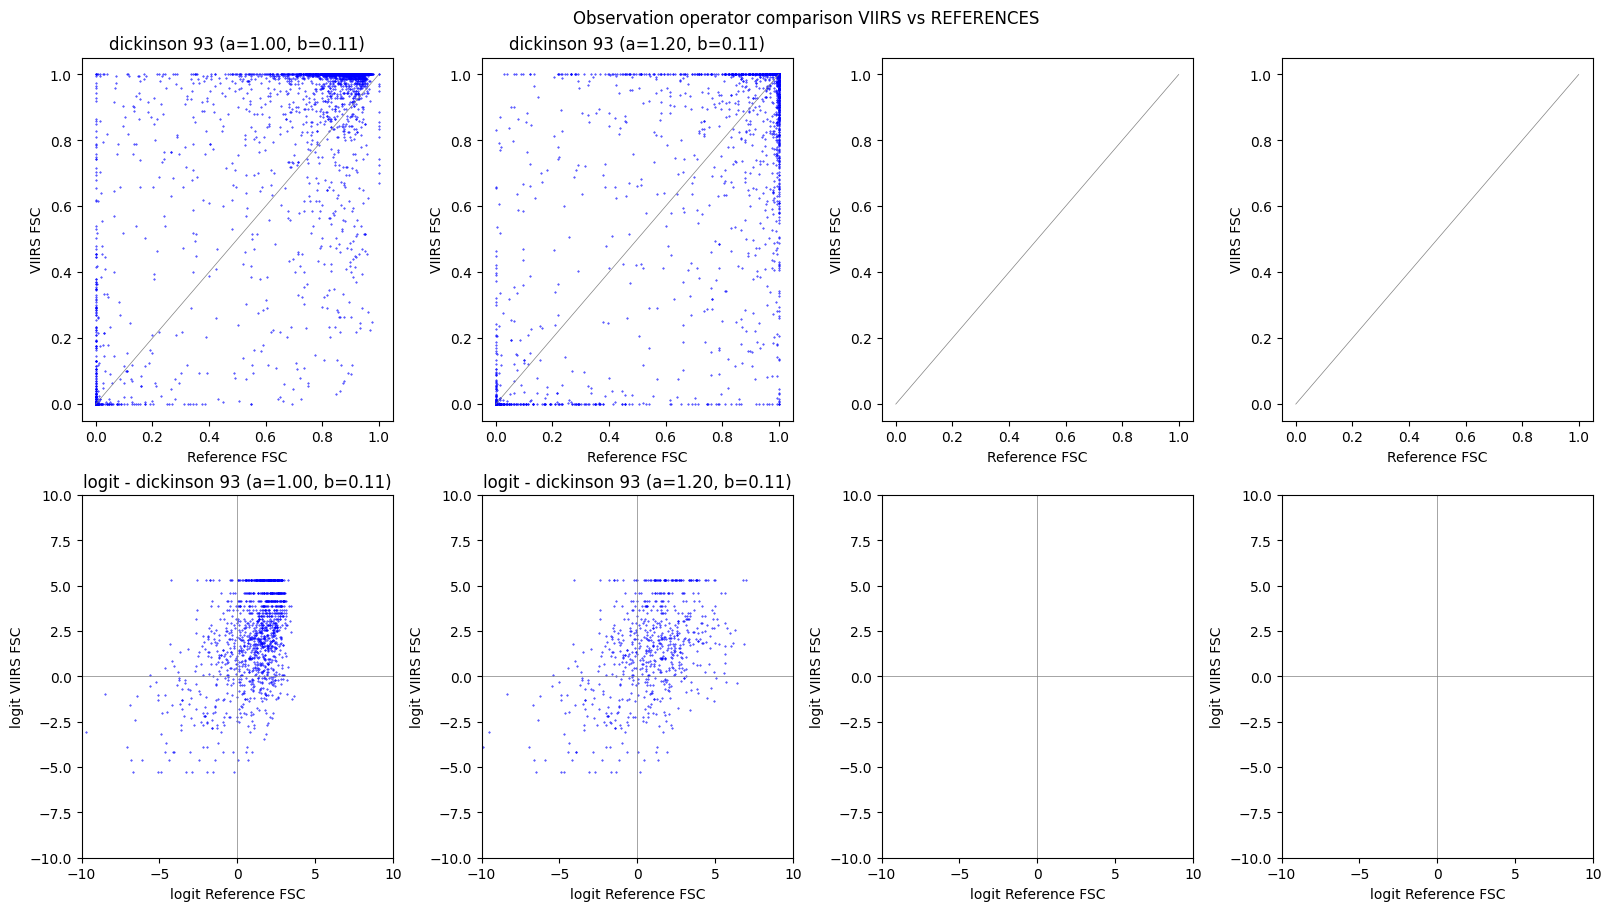

In [ ]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import logit
import numpy as np
from edelassim.evaluations import find_common_correspondences
from edelassim.observation_operators import dickinson, zaitchik
from edelassim.swe import sd_to_swe
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable


fig, axs = plt.subplots(2, 4, figsize=(16, 9), constrained_layout=True)
fig.suptitle("Observation operator comparison VIIRS vs REFERENCES")

sd_pleaides = pleiades.sel(x=viirs["x"], y=viirs["y"], method="nearest")
fsc_pleaides = dickinson(sd_pleaides, a0, b0)
fsc_pleaides = fsc_pleaides.where(fsc_pleaides >= 0).sel(band=1)
viirs_pleaides_passes = viirs.sel(time=pleiades.coords["time"], method="nearest").assign_coords({"time": fsc_pleaides.time})

viirs_pleaides_passes_correspondences, pleiades_correspondences = find_common_correspondences(
    data_1=viirs_pleaides_passes, data_2=fsc_pleaides
)


axs[0, 0].plot(pleiades_correspondences.ravel(), viirs_pleaides_passes_correspondences.ravel(), ".", color="b", markersize=0.8)
axs[0, 0].set_title(f"dickinson 93 (a={a0:.2f}, b={b0:.2f})")
axs[1, 0].plot(
    logit(pleiades_correspondences.ravel()),
    logit(viirs_pleaides_passes_correspondences.ravel()),
    ".",
    color="b",
    markersize=0.8,
)
axs[1, 0].set_title(f"logit - dickinson 93 (a={a0:.2f}, b={b0:.2f})")


sd_bdclim = bdclim.sel(time=viirs.coords["time"], method="nearest")
fsc_bdclim = dickinson(sd_bdclim, a0, 0)
viirs_station = viirs.sel(x=bdclim.coords["x"], y=bdclim.coords["y"], method="nearest").assign_coords(
    {"time": fsc_bdclim.time}
)

viirs_station_correspondences, bdclim_fsc_correspondences = find_common_correspondences(
    data_1=viirs_station, data_2=fsc_bdclim
)

axs[0, 0].plot(bdclim_fsc_correspondences.ravel(), viirs_station_correspondences.ravel(), ".", color="r", markersize=0.8)
axs[0, 0].set_title(f"dickinson 93 (a={a0:.2f}, b={b0:.2f})")
axs[1, 0].plot(
    logit(bdclim_fsc_correspondences.ravel()),
    logit(viirs_station_correspondences.ravel()),
    ".",
    color="b",
    markersize=0.8,
)
axs[1, 0].set_title(f"logit - dickinson 93 (a={a0:.2f}, b={b0:.2f})")

fsc_pleaides = dickinson(sd_pleaides, a_calib, b_calib)
fsc_pleaides = fsc_pleaides.where(fsc_pleaides >= 0).sel(band=1)
viirs_pleaides_passes = viirs.sel(time=pleiades.coords["time"], method="nearest").assign_coords({"time": fsc_pleaides.time})

viirs_pleaides_passes_correspondences, pleiades_correspondences = find_common_correspondences(
    data_1=viirs_pleaides_passes, data_2=fsc_pleaides
)

axs[0, 1].plot(viirs_pleaides_passes_correspondences.ravel(), pleiades_correspondences.ravel(), ".", color="b", markersize=0.8)
axs[0, 1].set_title(f"dickinson 93 (a={a_calib:.2f}, b={b_calib:.2f})")
axs[1, 1].plot(
    logit(pleiades_correspondences.ravel()),
    logit(viirs_pleaides_passes_correspondences.ravel()),
    ".",
    color="b",
    markersize=0.8,
)
axs[1, 1].set_title(f"logit - dickinson 93 (a={a_calib:.2f}, b={b_calib:.2f})")

for ax in axs[0, :]:
    ax.plot([0, 1], [0, 1], "gray", linewidth=0.5)
    ax.set_xlabel("Reference FSC")
    ax.set_ylabel("VIIRS FSC")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)


for ax in axs[1, :]:
    ax.plot([-10, 10], [0, 0], "gray", linewidth=0.5)
    ax.plot([0, 0], [-10, 10], "gray", linewidth=0.5)
    ax.set_xlabel("logit Reference FSC")
    ax.set_ylabel("logit VIIRS FSC")
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)


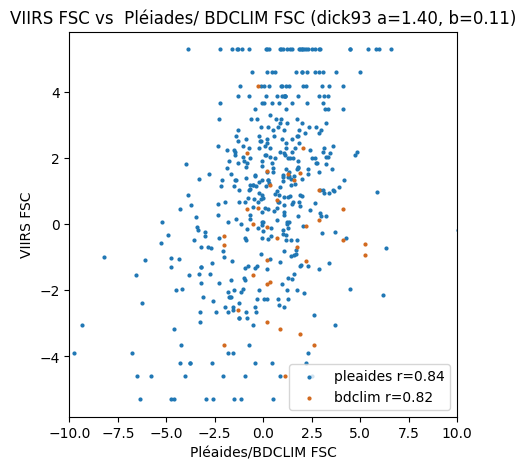

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from edelassim.observation_operators import dickinson
from edelassim.evaluations import find_common_correspondences
from scipy.special import logit

am, bm = 1.4, 0.11

fig, ax = plt.subplots(figsize=(5, 5))

sd_pleaides = pleiades.sel(x=viirs["x"], y=viirs["y"], method="nearest")
fsc_pleaides = dickinson(sd_pleaides, am, bm)
fsc_pleaides = fsc_pleaides.where(fsc_pleaides >= 0).sel(band=1)
viirs_pleaides_passes = viirs.sel(time=pleiades.coords["time"], method="nearest").assign_coords({"time": fsc_pleaides.time})


viirs_pleaides_passes_correspondences, pleiades_correspondences = find_common_correspondences(
    data_1=viirs_pleaides_passes, data_2=fsc_pleaides
)
r_virrs_pleaides_fsc = pearsonr(viirs_pleaides_passes_correspondences, pleiades_correspondences).statistic
ax.scatter(
    logit(pleiades_correspondences),
    logit(viirs_pleaides_passes_correspondences),
    s=4,
    label=f"pleaides r={r_virrs_pleaides_fsc:.2f}",
)

sd_bdclim = bdclim.sel(time=viirs.coords["time"], method="nearest")
fsc_bdclim = dickinson(sd_bdclim, am, bm)
viirs_station = viirs.sel(x=bdclim.coords["x"], y=bdclim.coords["y"], method="nearest").assign_coords(
    {"time": fsc_bdclim.time}
)

viirs_station_correspondences, bdclim_correspondences = find_common_correspondences(data_1=viirs_station, data_2=fsc_bdclim)
r_virrs_bdclim_fsc = pearsonr(viirs_station_correspondences, bdclim_correspondences).statistic
ax.scatter(
    logit(bdclim_correspondences),
    logit(viirs_station_correspondences),
    color="chocolate",
    s=4,
    label=f"bdclim r={r_virrs_bdclim_fsc:.2f}",
)

ax.set_title(f"VIIRS FSC vs  Pléiades/ BDCLIM FSC (dick93 a={am:.2f}, b={bm:.2f})")
ax.set_ylabel("VIIRS FSC")
ax.set_xlabel("Pléaides/BDCLIM FSC")
ax.set_xlim(-10, 10)
ax.legend()

{'whiskers': [<matplotlib.lines.Line2D at 0x700975c242e0>,
 'caps': [<matplotlib.lines.Line2D at 0x700975c248e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x700975bf7f40>],
 'medians': [<matplotlib.lines.Line2D at 0x700975c24ee0>],
 'fliers': [],
 'means': []}

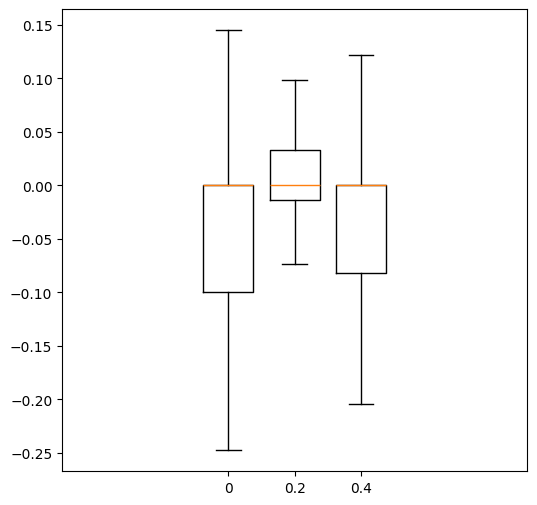

In [34]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(viirs_corr - pleaides_corr, positions=[0], showfliers=False)
ax.boxplot(viirs_s_corr - bdclim_corr, positions=[0.2], showfliers=False)
edel_fsc = dickinson(sd, am, bm)
residual_viirs_edel = (viirs - edel_fsc).values.ravel()
residual_viirs_edel = residual_viirs_edel[~np.isnan(residual_viirs_edel)]
# residual_viirs_edel
ax.boxplot(residual_viirs_edel, positions=[0.4], showfliers=False)

In [ ]:
from mountain_data_binner.mountain_binner import MountainBinner, MountainBinnerConfig

mb = MountainBinner.from_dem_and_forest_mask_filepath(
    dem_filepath="./dem_grandesrousses.nc",
    forest_mask_filepath="/home/imperatoren/work/edelweiss_assimilation/data/auxiliary/forest_mask/forest_mask_corine_grandesrousses_max.nc",
    distributed_data_filepath="viirs_edel_gr.nc",
    output_folder="./data/auxiliary",
)

INFO:logger:Opening distributed dataset in target geometry
INFO:logger:Opening DEM data
INFO:logger:Resampling DEM to output grid
INFO:logger:Exporting to ./output_folder/dem.tif
INFO:logger:Generating slope map
INFO:logger:Exported to ./output_folder/slope.tif
INFO:logger:Exported to ./output_folder/aspect.tif
INFO:logger:Opening distributed dataset un target geometry
INFO:logger:Opening forest mask data


0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [ ]:
import xarray as xr
import numpy as np


def calc_rmsd(ds: xr.Dataset):
    return np.sqrt((ds.viirs.values - ds.edel.values) ** 1)


mb.transform(
    distributed_data=xr.open_dataset("viirs_edel_gr.nc"),
    bin_dict=MountainBinner.create_default_bin_dict(altitude_step=3600),
    function=calc_rmsd,
)

MergeError: unable to determine if these variables should be coordinates or not in the merged result: {'spatial_ref'}